In [1]:
import numpy as np
import cv2
import glob


import os
from pathlib import Path

import sys
from matplotlib import pyplot as plt
%matplotlib inline

# Utility Functions

In [2]:
def save_coefficients(mtx, dist, path):
    """ Save the camera matrix and the distortion coefficients to given path/file. """
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_WRITE)
    cv_file.write("K", mtx)
    cv_file.write("D", dist)
    # note you *release* you don't close() a FileStorage object
    cv_file.release()

def load_coefficients(path):
    """ Loads camera matrix and distortion coefficients. """
    # FILE_STORAGE_READ
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_READ)

    # note we also have to specify the type to retrieve other wise we only get a
    # FileNode object back instead of a matrix
    camera_matrix = cv_file.getNode("K").mat()
    dist_matrix = cv_file.getNode("D").mat()

    cv_file.release()
    return [camera_matrix, dist_matrix]

def save_stereo_coefficients(path, K1, D1, K2, D2, R, T, E, F, R1, R2, P1, P2, Q):
    """ Save the stereo coefficients to given path/file. """
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_WRITE)
    cv_file.write("K1", K1)
    cv_file.write("D1", D1)
    cv_file.write("K2", K2)
    cv_file.write("D2", D2)
    cv_file.write("R", R)
    cv_file.write("T", T)
    cv_file.write("E", E)
    cv_file.write("F", F)
    cv_file.write("R1", R1)
    cv_file.write("R2", R2)
    cv_file.write("P1", P1)
    cv_file.write("P2", P2)
    cv_file.write("Q", Q)
    cv_file.release()


def load_coefficients(path):
    """ Loads camera matrix and distortion coefficients. """
    # FILE_STORAGE_READ
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_READ)

    # note we also have to specify the type to retrieve other wise we only get a
    # FileNode object back instead of a matrix
    camera_matrix = cv_file.getNode("K").mat()
    dist_matrix = cv_file.getNode("D").mat()

    cv_file.release()
    return [camera_matrix, dist_matrix]

    
def stereo_calibrate(left_file, right_file, left_dir, left_prefix, right_dir, right_prefix, image_format, save_file, square_size, width=6, height=9):
    """ Stereo calibration and rectification """
    objp, leftp, rightp = load_image_points(left_dir, left_prefix, right_dir, right_prefix, image_format, square_size, width, height)

    K1, D1 = load_coefficients(left_file)
    K2, D2 = load_coefficients(right_file)

    flag = 0
    # flag |= cv2.CALIB_FIX_INTRINSIC
    flag |= cv2.CALIB_USE_INTRINSIC_GUESS
    ret, K1, D1, K2, D2, R, T, E, F = cv2.stereoCalibrate(objp, leftp, rightp, K1, D1, K2, D2, image_size)
    print("Stereo calibration rms: ", ret)
    R1, R2, P1, P2, Q, roi_left, roi_right = cv2.stereoRectify(K1, D1, K2, D2, image_size, R, T, flags=cv2.CALIB_ZERO_DISPARITY, alpha=0.9)

    save_stereo_coefficients(save_file, K1, D1, K2, D2, R, T, E, F, R1, R2, P1, P2, Q)

def load_image_points(left_dir, left_prefix, right_dir, right_prefix, image_format, square_size, width=9, height=6):
    global image_size
    pattern_size = (width, height)  # Chessboard size!
    # prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,6,0)
    objp = np.zeros((height * width, 3), np.float32)
    objp[:, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)

    objp = objp * square_size  # Create real world coords. Use your metric.

    # Arrays to store object points and image points from all the images.
    objpoints = []  # 3d point in real world space
    left_imgpoints = []  # 2d points in image plane.
    right_imgpoints = []  # 2d points in image plane.

    # Left directory path correction. Remove the last character if it is '/'
    if left_dir[-1:] == '/':
        left_dir = left_dir[:-1]

    # Right directory path correction. Remove the last character if it is '/'
    if right_dir[-1:] == '/':
        right_dir = right_dir[:-1]

    # Get images for left and right directory. Since we use prefix and formats, both image set can be in the same dir.
    left_images = glob.glob(left_dir + '/' + left_prefix + '*.' + image_format)
    right_images = glob.glob(right_dir + '/' + right_prefix + '*.' + image_format)

    # Images should be perfect pairs. Otherwise all the calibration will be false.
    # Be sure that first cam and second cam images are correctly prefixed and numbers are ordered as pairs.
    # Sort will fix the globs to make sure.
    left_images.sort()
    right_images.sort()

    # Pairs should be same size. Otherwise we have sync problem.
    if len(left_images) != len(right_images):
        print("Numbers of left and right images are not equal. They should be pairs.")
        print("Left images count: ", len(left_images))
        print("Right images count: ", len(right_images))
        sys.exit(-1)

    pair_images = zip(left_images, right_images)  # Pair the images for single loop handling

    # Iterate through the pairs and find chessboard corners. Add them to arrays
    # If openCV can't find the corners in one image, we discard the pair.
    for left_im, right_im in pair_images:
        # Right Object Points
        right = cv2.imread(right_im)
        gray_right = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

        # Find the chess board corners
        ret_right, corners_right = cv2.findChessboardCorners(gray_right, pattern_size,
                                                             cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_FILTER_QUADS)

        # Left Object Points
        left = cv2.imread(left_im)
        gray_left = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)

        # Find the chess board corners
        ret_left, corners_left = cv2.findChessboardCorners(gray_left, pattern_size,
                                                           cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_FILTER_QUADS)

        if ret_left and ret_right:  # If both image is okay. Otherwise we explain which pair has a problem and continue
            # Object points
            objpoints.append(objp)
            # Right points
            corners2_right = cv2.cornerSubPix(gray_right, corners_right, (5, 5), (-1, -1), criteria)
            right_imgpoints.append(corners2_right)
            # Left points
            corners2_left = cv2.cornerSubPix(gray_left, corners_left, (5, 5), (-1, -1), criteria)
            left_imgpoints.append(corners2_left)
        else:
            print("Chessboard couldn't detected. Image pair: ", left_im, " and ", right_im)
            continue

    image_size = gray_right.shape  # If you have no acceptable pair, you may have an error here.
    return [objpoints, left_imgpoints, right_imgpoints]

def save_coefficients(mtx, dist, path):
    """ Save the camera matrix and the distortion coefficients to given path/file. """
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_WRITE)
    cv_file.write("K", mtx)
    cv_file.write("D", dist)
    # note you *release* you don't close() a FileStorage object
    cv_file.release()

def load_coefficients(path):
    """ Loads camera matrix and distortion coefficients. """
    # FILE_STORAGE_READ
    cv_file = cv2.FileStorage(path, cv2.FILE_STORAGE_READ)

    # note we also have to specify the type to retrieve other wise we only get a
    # FileNode object back instead of a matrix
    camera_matrix = cv_file.getNode("K").mat()
    dist_matrix = cv_file.getNode("D").mat()

    cv_file.release()
    return [camera_matrix, dist_matrix]     

# Explore

In [76]:
square_size = 0.025
width=9
height=6
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [33]:
images = glob.glob('./calibration_chess/*.jpg')

In [34]:
img = cv2.imread(images[0])

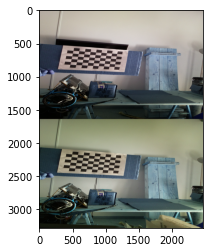

In [35]:
plt.imshow(img)

# Split Images

In [55]:
img_path = Path('./calibration_chess/')

In [37]:
img_dir = img_path.glob('*.jpg')

In [56]:
for file in img_path.glob('*.jpg'):
    
    img = cv2.imread(str(file))
    height, width = img.shape[:2]
    height_cutoff = height // 2
    s1 = img[:height_cutoff, :]
    
    s2 = img[height_cutoff:, :]

    #s1 = cv2.rotate(s1, cv2.ROTATE_90_CLOCKWISE)
    #s2 = cv2.rotate(s2, cv2.ROTATE_90_CLOCKWISE)

    # Save each half
    print(file.name[:-4]+"_u.jpg")
    cv2.imwrite(file.name[:-4]+"_u.jpg", s1)
    cv2.imwrite(file.name[:-4]+"_d.jpg", s2)

image1_u.jpg
image10_u.jpg
image11_u.jpg
image12_u.jpg
image13_u.jpg
image14_u.jpg
image15_u.jpg
image16_u.jpg
image17_u.jpg
image18_u.jpg
image19_u.jpg
image2_u.jpg
image20_u.jpg
image3_u.jpg
image4_u.jpg
image5_u.jpg
image6_u.jpg
image7_u.jpg
image8_u.jpg
image9_u.jpg


# Calibration of both the lenses

In [60]:
upImgs = Path('./up/')

#downImgs  = Path('./down/').glob('.jpg')

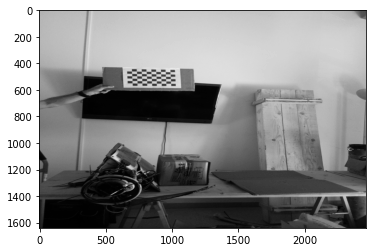

In [74]:
#test
img = cv2.imread(str(next(upImgs.glob('*.jpg'))))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray , cmap='gray')

In [70]:
ret, corners = cv2.findChessboardCorners(gray, (width, height), cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

In [ ]:
img = 

In [77]:
corners2 = cv2.cornerSubPix(img, corners, (11, 11), (-1, -1), criteria)
gray = cv2.drawChessboardCorners(img, (width, height), corners2, ret)

error: OpenCV(4.5.1) C:\Users\appveyor\AppData\Local\Temp\1\pip-req-build-kh7iq4w7\opencv\modules\imgproc\src\cornersubpix.cpp:58: error: (-215:Assertion failed) count >= 0 in function 'cv::cornerSubPix'


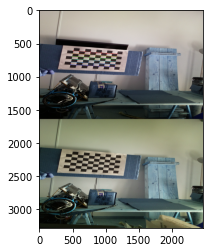

In [10]:
plt.imshow(img , cmap = 'gray')

In [11]:
# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,6,0)
objp = np.zeros((height*width, 3), np.float32)
objp[:, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)
objp = objp * square_size

In [12]:
objpoints = []  # 3d point in real world space
imgpoints = []  # 2d points in image plane.

In [13]:
objpoints.append(objp)
imgpoints.append(corners2)

In [19]:
imgpoints[0].shape

(54, 1, 2)

In [20]:
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

In [21]:
ret

0.7075039723309167

In [23]:
dist

array([[ 8.67025195e+00, -4.85965134e+01,  7.06851312e-01,
        -1.15663466e-01,  1.83741073e+03]])

In [25]:
ht,  wt = img.shape[:2]

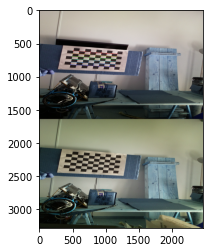

In [27]:
plt.imshow(img)

In [29]:
newcameramtx_u, roi=cv2.getOptimalNewCameraMatrix(mtx,dist,(wt,ht),1,(wt,ht))

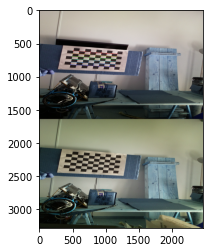

In [33]:
plt.imshow(img)

In [42]:
dst = cv2.undistort(img, mtx, dist, None, newcameramtx_u)

In [43]:
x,y,w,h = roi
dst = dst[0:y+h, 0:x+w]

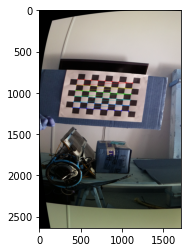

In [44]:
plt.imshow(dst)

# Calib test 2

In [3]:
dirpathU = '/up'
dirpathD = '/down'
prefix = 'image'
image_format = 'jpg'
square_size = 0.025
width=6
height=9
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [80]:

objp = np.zeros((9*6,3), np.float32)
objp[:,:2] = np.mgrid[0:9,0:6].T.reshape(-1,2)
img_ptsL = []
img_ptsR = []
obj_pts = []

for i in range(1,21):
	imgL = cv2.imread(dirpathU+'/' + prefix + str(i) +'_u.'+ image_format)
	imgR = cv2.imread(dirpathD+'/' + prefix + str(i) +'_d.'+ image_format)
	imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
	imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

	outputL = imgL.copy()
	outputR = imgR.copy()
	retR, cornersR =  cv2.findChessboardCorners(outputR,(9,6),None)
	retL, cornersL = cv2.findChessboardCorners(outputL,(9,6),None)
	if retR and retL:
		obj_pts.append(objp)
		cv2.cornerSubPix(imgR_gray,cornersR,(11,11),(-1,-1),criteria)
		cv2.cornerSubPix(imgL_gray,cornersL,(11,11),(-1,-1),criteria)
		cv2.drawChessboardCorners(outputR,(9,6),cornersR,retR)
		cv2.drawChessboardCorners(outputL,(9,6),cornersL,retL)
		plt.imshow(outputR)
		plt.show()
		#cv2.imshow('cornersR',outputR)
		plt.imshow(outputL)
		plt.show()
		#cv2.imshow('cornersL',outputL)
		#cv2.waitKey(0)
		img_ptsL.append(cornersL)
		img_ptsR.append(cornersR)

# Calibrating left camera

retL, mtxL, distL, rvecsL, tvecsL = cv2.calibrateCamera(obj_pts,img_ptsL,imgL_gray.shape[::-1],None,None)
hL,wL= imgL_gray.shape[:2]
new_mtxL, roiL= cv2.getOptimalNewCameraMatrix(mtxL,distL,(wL,hL),1,(wL,hL))

# Calibrating right camera

retR, mtxR, distR, rvecsR, tvecsR = cv2.calibrateCamera(obj_pts,img_ptsR,imgR_gray.shape[::-1],None,None)
hR,wR= imgR_gray.shape[:2]
new_mtxR, roiR= cv2.getOptimalNewCameraMatrix(mtxR,distR,(wR,hR),1,(wR,hR))

error: OpenCV(4.5.1) C:\Users\appveyor\AppData\Local\Temp\1\pip-req-build-kh7iq4w7\opencv\modules\imgproc\src\color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


# Back To square 0 : Calibration from https://python.plainenglish.io/the-depth-i-stereo-calibration-and-rectification-24da7b0fb1e0

In [8]:
dirpathU = '/up'
dirpathD = '/down'
prefix = 'image'
image_format = 'jpg'
square_size = 0.025
width=6
height=9
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

## Calibration of single cameras

In [4]:
left_images = glob.glob('./up/*.jpg')
right_images = glob.glob('./down/*.jpg')

left_images.sort()
right_images.sort()

### show some example

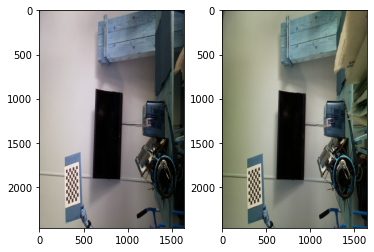

In [23]:
imgl = cv2.imread(left_images.pop())
imgr = cv2.imread(right_images.pop())
plt.subplot(121)
plt.imshow(imgl)

plt.subplot(122)
plt.imshow(imgr)

### LEFT

In [26]:
#def calibrate(dirpath, prefix, image_format, square_size, width=9, height=6):
""" Apply camera calibration operation for images in the given directory path. """
# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,6,0)
objp = np.zeros((height*width, 3), np.float32)
objp[:, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)

square_size = 0.025
objp = objp * square_size

# Arrays to store object points and image points from all the images.
objpoints = []  # 3d point in real world space
imgpoints = []  # 2d points in image plane.



In [11]:
objp.shape

(54, 3)

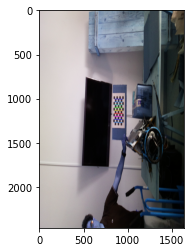

In [27]:

for fname in left_images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find the chess board corners
    ret, corners = cv2.findChessboardCorners(gray, (6, 9), None)

    # If found, add object points, image points (after refining them)
    if ret:
        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)

        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, (width, height), corners2, ret)
    plt.imshow(img)    
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)


In [28]:
save_coefficients(mtx , dist , './left_camera.yml')

### RIGHT

In [29]:
#def calibrate(dirpath, prefix, image_format, square_size, width=9, height=6):
""" Apply camera calibration operation for images in the given directory path. """
# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,6,0)
objp = np.zeros((height*width, 3), np.float32)
objp[:, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)

square_size = 0.025
objp = objp * square_size

# Arrays to store object points and image points from all the images.
objpoints = []  # 3d point in real world space
imgpoints = []  # 2d points in image plane.


for fname in right_images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find the chess board corners
    ret, corners = cv2.findChessboardCorners(gray, (6,9), None)

    # If found, add object points, image points (after refining them)
    if ret:
        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)

        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, (width, height), corners2, ret)

ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

In [30]:
save_coefficients(mtx , dist , './right_camera.yml')

## Stereo Calibrate + Rectification

In [5]:
# load from single camera calibration
K1, D1 = load_coefficients('left_camera.yml')
K2, D2 = load_coefficients('right_camera.yml')

In [6]:
left_images = glob.glob('./up/*.jpg')
right_images = glob.glob('./down/*.jpg')

left_images.sort()
right_images.sort()

pair_images = zip(left_images, right_images) 

In [33]:
square_size = 0.025
pattern_size = (6,9)  # Chessboard size!

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(8,6,0)
objp = np.zeros((height * width, 3), np.float32)
objp[:, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)

objp = objp * square_size  # Create real world coords. Use your metric.

# Arrays to store object points and image points from all the images.
objpoints = []  # 3d point in real world space
left_imgpoints = []  # 2d points in image plane.
right_imgpoints = []  # 2d points in image plane.

In [34]:
for left_im, right_im in pair_images:
        # Right Object Points
        right = cv2.imread(right_im)
        gray_right = cv2.cvtColor(right, cv2.COLOR_BGR2GRAY)

        # Find the chess board corners
        ret_right, corners_right = cv2.findChessboardCorners(gray_right, pattern_size,
                                                             cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_FILTER_QUADS)

        # Left Object Points
        left = cv2.imread(left_im)
        gray_left = cv2.cvtColor(left, cv2.COLOR_BGR2GRAY)

        # Find the chess board corners
        ret_left, corners_left = cv2.findChessboardCorners(gray_left, pattern_size,
                                                           cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_FILTER_QUADS)

        if ret_left and ret_right:  # If both image is okay. Otherwise we explain which pair has a problem and continue
            # Object points
            objpoints.append(objp)
            # Right points
            corners2_right = cv2.cornerSubPix(gray_right, corners_right, (5, 5), (-1, -1), criteria)
            right_imgpoints.append(corners2_right)
            # Left points
            corners2_left = cv2.cornerSubPix(gray_left, corners_left, (5, 5), (-1, -1), criteria)
            left_imgpoints.append(corners2_left)
        else:
            print("Chessboard couldn't detected. Image pair: ", left_im, " and ", right_im)
            continue

  # If you have no acceptable pair, you may have an error here.


Chessboard couldn't detected. Image pair:  ./up\image11_u.jpg  and  ./down\image11_d.jpg


In [18]:
len(objpoints) , len(left_imgpoints) , len(right_imgpoints)

(19, 19, 19)

In [35]:
image_size = None

In [36]:
flag = 0
# flag |= cv2.CALIB_FIX_INTRINSIC
flag |= cv2.CALIB_USE_INTRINSIC_GUESS
ret, K1, D1, K2, D2, R, T, E, F = cv2.stereoCalibrate(objpoints, left_imgpoints, right_imgpoints, K1, D1, K2, D2, image_size)
print("Stereo calibration rms: ", ret)
R1, R2, P1, P2, Q, roi_left, roi_right = cv2.stereoRectify(K1, D1, K2, D2, image_size, R, T, flags=cv2.CALIB_ZERO_DISPARITY, alpha=0.9) #try alpha = -1


Stereo calibration rms:  26.164730708059484


In [37]:
save_stereo_coefficients('stereo_coefficients.yml', K1, D1, K2, D2, R, T, E, F, R1, R2, P1, P2, Q)

## TEST

In [38]:
left_test = cv2.imread(list(left_images)[0])
right_test = cv2.imread(list(right_images)[0])

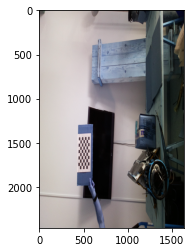

In [39]:
plt.imshow(left_test)

In [40]:
leftMapX, leftMapY = cv2.initUndistortRectifyMap(K1, D1, R1, P1, (width, height), cv2.CV_32FC1)
left_rectified = cv2.remap(left_test, leftMapX, leftMapY, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
rightMapX, rightMapY = cv2.initUndistortRectifyMap(K2, D2, R2, P2, (width, height), cv2.CV_32FC1)
right_rectified = cv2.remap(right_test, rightMapX, rightMapY, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)

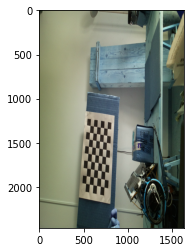

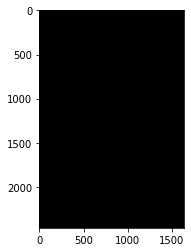

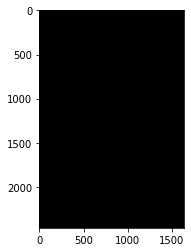

In [43]:
p = np.arange(0.5, 0.6, 0.1)


#rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR= cv2.stereoRectify(new_mtxL, distL, new_mtxR, distR, imgL_gray.shape[::-1], Rot, Trns, rectify_scale,(0,0))
rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR= cv2.stereoRectify(K1, D1, K2, D2, image_size, R, T, flags=cv2.CALIB_ZERO_DISPARITY, alpha=0.5)

#test Image
left_image = cv2.imread('./up/image1_u.jpg')
right_image = cv2.imread('./down/image1_d.jpg')
height, width = right_image.shape[:2]

#plt.imshow(right_image)
#plt.show()

Left_Stereo_Map= cv2.initUndistortRectifyMap(K1, D1, R1, P1, (width, height), cv2.CV_32FC1)
Right_Stereo_Map= cv2.initUndistortRectifyMap(K2, D2, R2, P2, (width, height), cv2.CV_32FC1)

Left_nice= cv2.remap(left_image,Left_Stereo_Map[0],Left_Stereo_Map[1], cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
Right_nice= cv2.remap(right_image,Right_Stereo_Map[0],Right_Stereo_Map[1], cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
plt.imshow(Left_nice)
plt.show()
plt.imshow(Right_nice)
plt.show()

### other parameters

In [3]:
cv_file = cv2.FileStorage("improved_params2.xml", cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()

In [4]:
left_image = cv2.imread('./up/image1_u.jpg')
right_image = cv2.imread('./down/image1_d.jpg')
height, width = right_image.shape[:2]

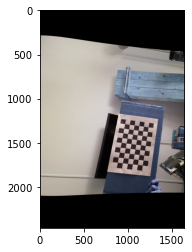

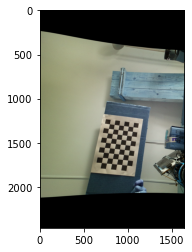

In [5]:
Left_nice= cv2.remap(left_image,Left_Stereo_Map_x,Left_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
Right_nice= cv2.remap(right_image,Right_Stereo_Map_x,Right_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
plt.imshow(Left_nice)
plt.show()
plt.imshow(Right_nice)
plt.show()

In [23]:
def depth_map(imgL, imgR):
    """ Depth map calculation. Works with SGBM and WLS. Need rectified images, returns depth map ( left to right disparity ) """
    # SGBM Parameters -----------------
    window_size= 15  # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely

    left_matcher = cv2.StereoSGBM_create(
        minDisparity=1, # Andrea changed from -1
        numDisparities=5*16,  # max_disp has to be dividable by 16 f. E. HH 192, 256
        blockSize=window_size,
        P1=8 * 3 * window_size,
        # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely
        P2=32 * 3 * window_size,
        disp12MaxDiff=12,
        uniquenessRatio=10,
        speckleWindowSize=50,
        speckleRange=32,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )
    right_matcher = cv2.ximgproc.createRightMatcher(left_matcher)
    # FILTER Parameters
    lmbda = 80000
    sigma = 1.3
    visual_multiplier = 6

    wls_filter = cv2.ximgproc.createDisparityWLSFilter(matcher_left=left_matcher)
    wls_filter.setLambda(lmbda)

    wls_filter.setSigmaColor(sigma)
    displ = left_matcher.compute(imgL, imgR)  # .astype(np.float32)/16
    dispr = right_matcher.compute(imgR, imgL)  # .astype(np.float32)/16
    displ = np.int16(displ)
    dispr = np.int16(dispr)
    filteredImg = wls_filter.filter(displ, imgL, None, dispr)  # important to put "imgL" here!!!

    filteredImg = cv2.normalize(src=filteredImg, dst=filteredImg, beta=0, alpha=255, norm_type=cv2.NORM_MINMAX);
    filteredImg = np.uint8(filteredImg)

    return filteredImg

In [24]:
gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRAY)
disparity_image = depth_map(gray_left, gray_right)

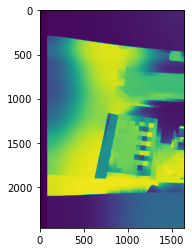

In [25]:
plt.imshow(disparity_image)
plt.show()

In [26]:
left_image = cv2.imread('./up/image10_u.jpg')
right_image = cv2.imread('./down/image10_d.jpg')
Left_nice= cv2.remap(left_image,Left_Stereo_Map_x,Left_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
Right_nice= cv2.remap(right_image,Right_Stereo_Map_x,Right_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)

In [27]:
gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRAY)
disparity_image = depth_map(gray_left, gray_right)

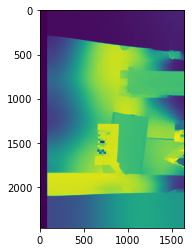

In [28]:
plt.imshow(disparity_image)

# Fish

In [16]:
def disparity_img(left_img_path : str , right_img_path : str):
    left_image = cv2.imread(left_img_path)
    right_image = cv2.imread(right_img_path)
    Left_nice= cv2.remap(left_image,Left_Stereo_Map_x,Left_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
    Right_nice= cv2.remap(right_image,Right_Stereo_Map_x,Right_Stereo_Map_y, cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
    gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_RGB2GRAY)
    gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_RGB2GRAY)    
    #gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
    #gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRreturny_image = depth_map(gray_leftght)ty_image)
    return depth_map(gray_left, gray_right)

In [17]:
fish_up = glob.glob('./fup/*.jpg')
fish_down = glob.glob('./fdown/*.jpg')   
fish_up = list(fish_up)
fish_down = list(fish_down)

In [33]:
f1 , f2 = fish_up[2] , fish_down[2]

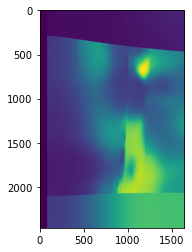

In [34]:
plt.imshow(disparity_img(f1 , f2))

In [31]:
from PIL import Image

In [ ]:
Image.open(fish_up[0])

In [7]:
fish_up = list(glob.glob('./fup/*.jpg'))
fish_down = list(glob.glob('./fdown/*.jpg'))   

In [1]:
cv2.imread(fish_up[1],cv2.IMREAD_COLOR )

NameError: name 'cv2' is not defined

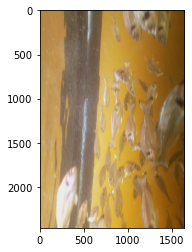

In [37]:
i = 8
plt.subplot(121)
plt.imshow(cv2.imread(fish_up[i] , for))
           
#show_disparity_img(fish_up[i],fish_down[i])

In [19]:
from PIL import Image

In [ ]:
Image.open(fish_up[0])

In [ ]:
i = 8
plt.subplot(121)
Image.open(fish_up[i])